#### Import Libraries

In [2]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

#### Load & Preprocess Dataset

In [3]:
# Load dataset
X, y = load_digits(return_X_y=True)

# Scale features
X = StandardScaler().fit_transform(X)

# First split: train + temp (val+test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Second split: validation + test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=42
)

print("Train size:", len(X_train))
print("Validation size:", len(X_val))
print("Test size:", len(X_test))


Train size: 1257
Validation size: 270
Test size: 270


#### Build ANN Model

In [4]:
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(10, activation='softmax')  # 10 digit classes
])


G:\DS\ML for teens\venv\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


#### Compile Model

In [5]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


#### Train Model (with Validation)

In [6]:
history = model.fit(
    X_train, y_train,
    epochs=25,
    batch_size=16,
    validation_data=(X_val, y_val)
)


Epoch 1/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.5235 - loss: 1.6135 - val_accuracy: 0.8296 - val_loss: 0.8624
Epoch 2/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.8711 - loss: 0.6145 - val_accuracy: 0.9111 - val_loss: 0.3855
Epoch 3/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9411 - loss: 0.2876 - val_accuracy: 0.9444 - val_loss: 0.2350
Epoch 4/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9634 - loss: 0.1695 - val_accuracy: 0.9444 - val_loss: 0.1805
Epoch 5/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9769 - loss: 0.1149 - val_accuracy: 0.9593 - val_loss: 0.1469
Epoch 6/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9881 - loss: 0.0823 - val_accuracy: 0.9667 - val_loss: 0.1257
Epoch 7/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9905 - loss: 0.0608 - val_accuracy: 0.9667 - val_loss: 0.1231
Epoch 8/25
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9960 - loss: 0.0464 - val_accuracy: 0.9704 - val_

#### Final Test Evaluation

In [7]:
loss, acc = model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {acc:.2f}")


9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - accuracy: 0.9778 - loss: 0.1060
Final Test Accuracy: 0.98


In [8]:
# Evaluate on training set
train_loss, train_acc = model.evaluate(X_train, y_train)
print(f"Train Accuracy: {train_acc:.2f}")

# Evaluate on test set
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.2f}")


40/40 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 1.0000 - loss: 0.0023
Train Accuracy: 1.00
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9778 - loss: 0.1060
Test Accuracy: 0.98


#### Plot both loss and accuracy curves over epochs

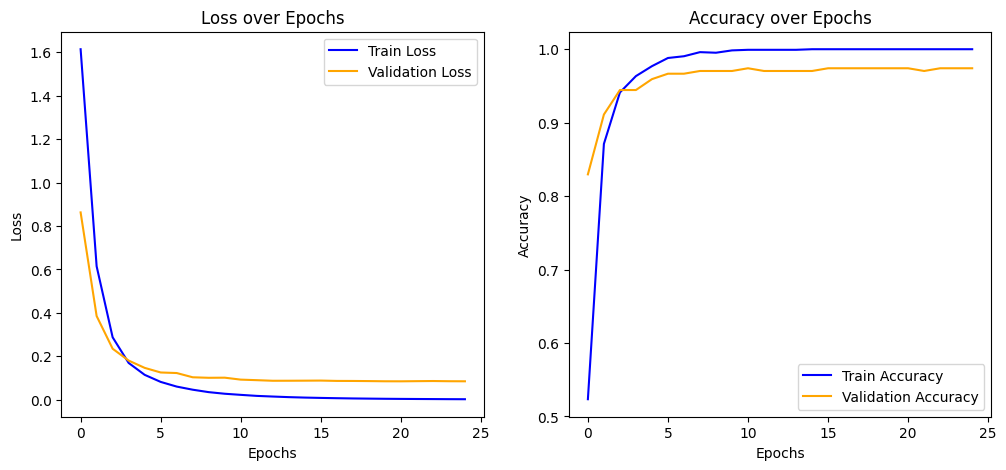

In [9]:
import matplotlib.pyplot as plt

# Assume you have a Keras history object from model.fit()
# history.history contains 'loss', 'val_loss', 'accuracy', 'val_accuracy'

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Plot Loss
ax1.plot(history.history['loss'], label='Train Loss', color='blue')
ax1.plot(history.history['val_loss'], label='Validation Loss', color='orange')
ax1.set_title('Loss over Epochs')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Loss')
ax1.legend()

# Plot Accuracy
ax2.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
ax2.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
ax2.set_title('Accuracy over Epochs')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

plt.show()
